# Manufacturing Quality Analytics — Data Pipeline
## Bronze → Silver → Gold | AWS S3 + Athena + Power BI

**Author:** Aman Kag  
**Architecture:** AWS Medallion (Bronze -> Silver -> Gold)  
**Storage:** AWS S3 (ap-southeast-2) | **Query:** AWS Athena | **BI:** Power BI Desktop

### Pipeline Stages
| Stage | Description |
|---|---|
| 1. Load | Read raw Bronze data from AWS S3 |
| 2. EDA | Profile nulls, distributions, categories, outliers |
| 3. Clean | Apply targeted fixes → Silver layer |
| 4. Validate | 8-rule data quality report |
| 5. Anomaly Detection | Isolation Forest (unsupervised ML) |
| 6. Machine Clustering | K-Means (unsupervised ML) |
| 7. Aggregate | Build 4 Gold layer analytical tables |
| 8. Export | Parquet to AWS S3 (hash-checked, no redundant uploads) |

> **Note:** AWS credentials are loaded from the local environment (`~/.aws/credentials`).  
> No credentials are stored or exposed in this notebook.

## 1. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hashlib
import os
import math
import boto3
import s3fs
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)

print("Libraries loaded successfully")
print(f"Pandas  : {pd.__version__}")
print(f"NumPy   : {np.__version__}")

Libraries loaded successfully
Pandas  : 2.3.3
NumPy   : 2.2.6


### Environment Configuration

Set `ENV = "s3"` to read/write directly from AWS S3.  
Set `ENV = "local"` for local development without AWS connectivity.  
All thresholds and ML parameters are centralised here for reproducibility.

In [2]:
# ── ENVIRONMENT ──────────────────────────────────────────────────
ENV = "local"   # "local" | "s3"

# ── AWS S3 ───────────────────────────────────────────────────────
# Credentials loaded from ~/.aws/credentials (aws configure)
# No credentials stored in this notebook
S3_BUCKET  = "manufacturing-analytics-aman-2026"
AWS_REGION = "ap-southeast-2"

S3_BRONZE_PATH = f"s3://{S3_BUCKET}/bronze/manufacturing_dataset.csv"
S3_SILVER_PATH = f"s3://{S3_BUCKET}/silver/manufacturing_silver_clean.csv"
S3_DQ_PATH     = f"s3://{S3_BUCKET}/silver/data_quality_report.csv"
S3_GOLD_PREFIX = f"s3://{S3_BUCKET}/gold/"

# ── LOCAL PATHS ───────────────────────────────────────────────────
LOCAL_BRONZE_PATH = "data/bronze/manufacturing_dataset.csv"
LOCAL_SILVER_PATH = "data/silver/manufacturing_silver_clean.csv"
LOCAL_DQ_PATH     = "data/silver/data_quality_report.csv"
LOCAL_GOLD_DIR    = "data/gold/"

# ── ACTIVE PATHS ─────────────────────────────────────────────────
BRONZE_PATH = S3_BRONZE_PATH if ENV == "s3" else LOCAL_BRONZE_PATH
SILVER_PATH = S3_SILVER_PATH if ENV == "s3" else LOCAL_SILVER_PATH
DQ_PATH     = S3_DQ_PATH     if ENV == "s3" else LOCAL_DQ_PATH
GOLD_DIR    = S3_GOLD_PREFIX if ENV == "s3" else LOCAL_GOLD_DIR

# ── DASHBOARD RANGE ───────────────────────────────────────────────
DASHBOARD_START_YEAR = 2021
DASHBOARD_END_YEAR   = 2025

# ── CLEANING THRESHOLDS ───────────────────────────────────────────
SCRAP_RATE_MAX     = 0.5   # Physical impossibility threshold (>= 50% scrap rate)
SCRAP_DECIMAL_TYPO = 1.0   # Values > 1.0 indicate decimal entry errors (e.g. 3.6 → 0.036)

# ── ML PARAMETERS ────────────────────────────────────────────────
IF_CONTAMINATION    = 0.02  # Expected anomaly proportion (~2%)
IF_N_ESTIMATORS     = 100
KMEANS_CLUSTERS     = 3     # Critical / Monitor / Good
KMEANS_RANDOM_STATE = 42

if ENV == "local":
    os.makedirs("data/bronze", exist_ok=True)
    os.makedirs("data/silver", exist_ok=True)
    os.makedirs("data/gold",   exist_ok=True)

print(f"Environment  : {ENV.upper()}")
print(f"Bronze source: {BRONZE_PATH}")
print(f"Silver output: {SILVER_PATH}")
print(f"Gold output  : {GOLD_DIR}")

Environment  : LOCAL
Bronze source: data/bronze/manufacturing_dataset.csv
Silver output: data/silver/manufacturing_silver_clean.csv
Gold output  : data/gold/


## 2. Load Bronze Layer

Raw source data ingested without any transformations also  
Bronze is the immutable record of the original dataset. So data is loaded as it is. 

In [3]:
#Loading data from aws server having raw data in bronze layer. 
if ENV == "s3":
    fs = s3fs.S3FileSystem()
    with fs.open(BRONZE_PATH) as f:
        df_bronze = pd.read_csv(f)
else:
    df_bronze = pd.read_csv(BRONZE_PATH)

print(f"Source : {BRONZE_PATH}")
print(f"Shape  : {df_bronze.shape[0]:,} rows x {df_bronze.shape[1]} columns")

Source : data/bronze/manufacturing_dataset.csv
Shape  : 3,000 rows x 22 columns


In [4]:
#checking data type - 
print(df_bronze.dtypes)

Production ID                       int64
Date                               object
Product Type                       object
Machine ID                          int64
Shift                              object
Units Produced                    float64
Defects                           float64
Production Time Hours             float64
Material Cost Per Unit            float64
Labour Cost Per Hour              float64
Energy Consumption kWh            float64
Operator Count                    float64
Maintenance Hours                 float64
Down time Hours                   float64
Production Volume Cubic Meters    float64
Scrap Rate                        float64
Rework Hours                      float64
Quality Checks Failed             float64
Average Temperature C             float64
Average Humidity Percent          float64
Opportunities Per Unit            float64
Defect Type                        object
dtype: object


In [5]:
#Summary of table -
df_bronze.describe().round(3)

,Production ID,Machine ID,Units Produced,Defects,Production Time Hours,Material Cost Per Unit,Labour Cost Per Hour,Energy Consumption kWh,Operator Count,Maintenance Hours,Down time Hours,Production Volume Cubic Meters,Scrap Rate,Rework Hours,Quality Checks Failed,Average Temperature C,Average Humidity Percent,Opportunities Per Unit
count,3000.00,3000.000,2946.000,2651.000,2862.000,2742.000,3000.000,2862.000,2886.000,2700.000,2591.000,3000.000,2955.000,2488.000,2707.000,3000.000,3000.000,3000.000
mean,1500.50,10.259,126.758,5.081,12.556,30.412,22.643,299.503,2.491,2.507,1.536,1.513,0.035,1.004,0.992,21.602,45.008,7.240
std,866.17,5.753,46.234,8.774,6.924,12.139,4.397,114.516,1.119,1.444,0.879,0.577,0.113,0.576,0.801,2.046,8.586,1.747
min,1.00,1.000,50.000,0.000,1.000,3.000,15.000,100.040,1.000,0.000,0.000,0.500,0.010,0.000,0.000,18.000,30.000,5.000
25%,750.75,5.000,87.000,2.000,6.792,20.373,18.810,199.265,1.000,1.240,0.780,1.018,0.020,0.500,0.000,19.800,37.500,6.000
50%,1500.50,10.000,127.000,5.000,12.355,30.050,22.770,299.415,2.000,2.490,1.570,1.510,0.031,1.010,1.000,21.700,45.000,7.000
75%,2250.25,15.000,164.000,7.000,18.305,40.198,26.492,400.015,3.000,3.760,2.310,2.010,0.040,1.490,2.000,23.400,52.200,8.000
max,3000.00,20.000,406.770,188.000,50.000,98.413,30.000,499.960,4.000,5.000,3.000,2.500,4.100,2.000,2.000,25.000,60.000,10.000


In [6]:
#Initial some rows from the table - 
df_bronze.head()

,Production ID,Date,Product Type,Machine ID,Shift,Units Produced,Defects,Production Time Hours,Material Cost Per Unit,Labour Cost Per Hour,Energy Consumption kWh,Operator Count,Maintenance Hours,Down time Hours,Production Volume Cubic Meters,Scrap Rate,Rework Hours,Quality Checks Failed,Average Temperature C,Average Humidity Percent,Opportunities Per Unit,Defect Type
0,1,2020-01-01,Automotive,3,Swing,142.0,3.0,23.42,38.68,15.38,NaN,1.0,4.86,1.57,2.34,0.048,1.65,1.0,22.8,47.2,10.0,Scratch
1,2,2020-01-02,Textiles,8,Night,170.0,4.0,7.51,21.35,25.36,181.16,2.0,2.51,0.18,1.52,0.030,NaN,1.0,23.8,37.9,5.0,Fabric Tear
2,3,2020-01-03,Appliances,11,Swing,182.0,4.0,20.58,47.54,16.46,452.15,2.0,0.34,2.88,0.57,0.026,0.26,0.0,24.5,56.1,7.0,Wiring Issue
3,4,2020-01-04,Appliances,11,Day,133.0,NaN,21.68,40.21,28.70,485.78,3.0,4.64,NaN,1.90,0.036,NaN,2.0,22.3,50.8,7.0,Assembly Fault
4,5,2020-01-05,Electronics,14,Night,82.0,NaN,16.68,NaN,17.20,315.58,1.0,2.29,0.02,2.25,0.020,0.67,0.0,23.4,53.9,8.0,Overheating


## 3. Schema Standardisation

Applied before EDA to ensure all downstream analysis uses consistent column names.

- Strip leading/trailing whitespace from column names
- Replace spaces with underscores
- Convert to lowercase (snake_case)
- Cast `date` to datetime and extract year/month/day

In [7]:
# Making a copy of data to perform all further actions only on copy of raw data.
df = df_bronze.copy()

In [9]:
# Making clean column names by eliminating any spaces, replacing middle spaces between word with _, also lowering the case.
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.lower()

In [10]:
# converting date column into date datatype, if error comes make 'Not a time' rather crashing.
df['date'] = pd.to_datetime(df['date'], errors='coerce', infer_datetime_format=True)

#If there are any invalid dates than we can handle it using loop and dropping such rows - 
invalid_dates = df[df['date'].isna()]
if len(invalid_dates) > 0:
    print(f"Dropping {len(invalid_dates)} rows with unparseable dates")
    df = df.dropna(subset=['date'])

In [11]:
# Extracting date objects and making new columns, here date objects are year,month,day.
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day']   = df['date'].dt.day

In [12]:
#Printing all info - 
print(f"Columns ({len(df.columns)}):")
print(list(df.columns))
print(f"\nDate range : {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Years      : {sorted(df['year'].unique().tolist())}")
print(f"Rows       : {len(df):,}")

Columns (25):
['production_id', 'date', 'product_type', 'machine_id', 'shift', 'units_produced', 'defects', 'production_time_hours', 'material_cost_per_unit', 'labour_cost_per_hour', 'energy_consumption_kwh', 'operator_count', 'maintenance_hours', 'down_time_hours', 'production_volume_cubic_meters', 'scrap_rate', 'rework_hours', 'quality_checks_failed', 'average_temperature_c', 'average_humidity_percent', 'opportunities_per_unit', 'defect_type', 'year', 'month', 'day']

Date range : 2020-01-01 to 2028-03-18
Years      : [2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028]
Rows       : 3,000


## 4. Exploratory Data Analysis

Each cleaning decision in Section 5 is motivated by a specific finding in this section.  
EDA is conducted on raw (pre-clean) data to avoid circular reasoning.

### 4.1 Dataset Overview

In [13]:
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nNumeric columns ({len(df.select_dtypes(include='number').columns)}):")
print(df.select_dtypes(include='number').columns.tolist())
print(f"\nCategorical columns ({len(df.select_dtypes(include='object').columns)}):")
print(df.select_dtypes(include='object').columns.tolist())

Shape: 3,000 rows x 25 columns

Numeric columns (21):
['production_id', 'machine_id', 'units_produced', 'defects', 'production_time_hours', 'material_cost_per_unit', 'labour_cost_per_hour', 'energy_consumption_kwh', 'operator_count', 'maintenance_hours', 'down_time_hours', 'production_volume_cubic_meters', 'scrap_rate', 'rework_hours', 'quality_checks_failed', 'average_temperature_c', 'average_humidity_percent', 'opportunities_per_unit', 'year', 'month', 'day']

Categorical columns (3):
['product_type', 'shift', 'defect_type']


In [14]:
df.describe().round(3)

,production_id,date,machine_id,units_produced,defects,production_time_hours,material_cost_per_unit,labour_cost_per_hour,energy_consumption_kwh,operator_count,maintenance_hours,down_time_hours,production_volume_cubic_meters,scrap_rate,rework_hours,quality_checks_failed,average_temperature_c,average_humidity_percent,opportunities_per_unit,year,month,day
count,3000.00,3000,3000.000,2946.000,2651.000,2862.000,2742.000,3000.000,2862.000,2886.000,2700.000,2591.000,3000.000,2955.000,2488.000,2707.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000
mean,1500.50,2024-02-08 12:14:24,10.259,126.758,5.081,12.556,30.412,22.643,299.503,2.491,2.507,1.536,1.513,0.035,1.004,0.992,21.602,45.008,7.240,2023.616,6.401,15.688
min,1.00,2020-01-01 00:00:00,1.000,50.000,0.000,1.000,3.000,15.000,100.040,1.000,0.000,0.000,0.500,0.010,0.000,0.000,18.000,30.000,5.000,2020.000,1.000,1.000
25%,750.75,2022-01-19 18:00:00,5.000,87.000,2.000,6.792,20.373,18.810,199.265,1.000,1.240,0.780,1.018,0.020,0.500,0.000,19.800,37.500,6.000,2022.000,3.000,8.000
50%,1500.50,2024-02-08 12:00:00,10.000,127.000,5.000,12.355,30.050,22.770,299.415,2.000,2.490,1.570,1.510,0.031,1.010,1.000,21.700,45.000,7.000,2024.000,6.000,16.000
75%,2250.25,2026-02-27 06:00:00,15.000,164.000,7.000,18.305,40.198,26.492,400.015,3.000,3.760,2.310,2.010,0.040,1.490,2.000,23.400,52.200,8.000,2026.000,9.000,23.000
max,3000.00,2028-03-18 00:00:00,20.000,406.770,188.000,50.000,98.413,30.000,499.960,4.000,5.000,3.000,2.500,4.100,2.000,2.000,25.000,60.000,10.000,2028.000,12.000,31.000
std,866.17,NaN,5.753,46.234,8.774,6.924,12.139,4.397,114.516,1.119,1.444,0.879,0.577,0.113,0.576,0.801,2.046,8.586,1.747,2.373,3.487,8.796


### 4.2 Null Value Analysis

Quantifying missing data per column to determine imputation scope and strategy.

In [15]:
missing_counts   = df.isnull().sum()
missing_pct_data = (df.isnull().mean() * 100).round(2)

missing_summary = (
    pd.DataFrame({
        'missing_count'   : missing_counts,
        'missing_pct_data': missing_pct_data
    })
    .sort_values('missing_pct_data', ascending=False)
)

print(f"Total nulls: {df.isnull().sum().sum():,} across {(df.isnull().sum() > 0).sum()} columns")
print()
print(missing_summary[missing_summary['missing_count'] > 0])

Total nulls: 2,769 across 12 columns

                        missing_count  missing_pct_data
rework_hours                      512             17.07
down_time_hours                   409             13.63
defects                           349             11.63
maintenance_hours                 300             10.00
quality_checks_failed             293              9.77
material_cost_per_unit            258              8.60
defect_type                       159              5.30
production_time_hours             138              4.60
energy_consumption_kwh            138              4.60
operator_count                    114              3.80
units_produced                     54              1.80
scrap_rate                         45              1.50


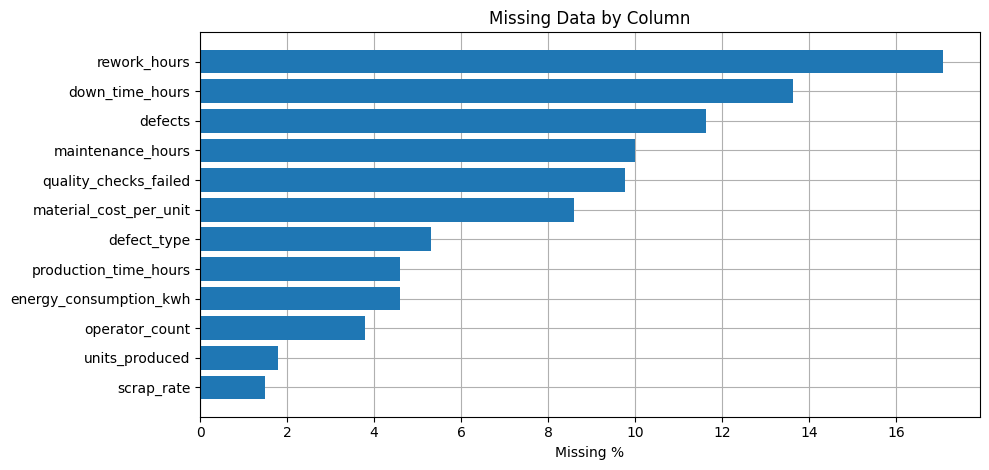

In [16]:
ms = missing_summary[missing_summary['missing_count'] > 0]

if len(ms) > 0:
    plt.figure(figsize=(10, max(3, 0.4 * len(ms))))
    plt.barh(ms.index, ms['missing_pct_data'], zorder=2)
    plt.grid(True, zorder=1)
    plt.xlabel('Missing %')
    plt.title('Missing Data by Column')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

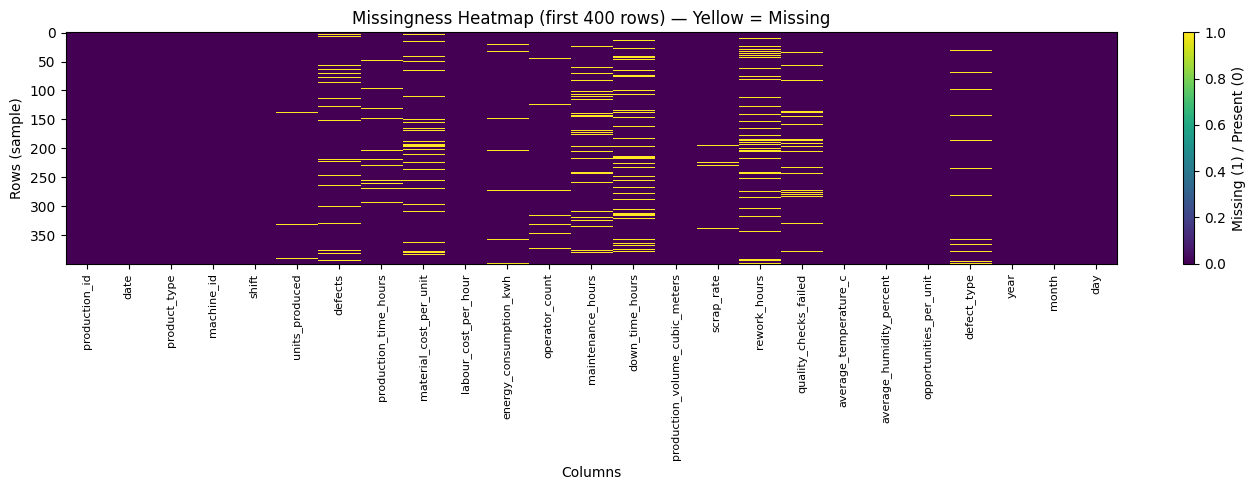

In [17]:
mask        = df.isna()
sample_n    = min(400, len(mask))
mask_sample = mask.head(sample_n)

plt.figure(figsize=(14, 5))
plt.imshow(mask_sample.values, aspect='auto', interpolation='nearest')
plt.title(f'Missingness Heatmap (first {sample_n} rows) — Yellow = Missing')
plt.xlabel('Columns')
plt.ylabel('Rows (sample)')
plt.xticks(ticks=np.arange(len(mask_sample.columns)),
           labels=mask_sample.columns, rotation=90, fontsize=8)
plt.colorbar(label='Missing (1) / Present (0)')
plt.tight_layout()
plt.show()

### 4.3 Null Distribution by Shift and Year

Determines whether missingness is random or concentrated in specific operational segments.  
Random distribution across shifts and years supports group median imputation over deletion.

In [18]:
null_cols = missing_summary[missing_summary['missing_count'] > 0].index.tolist()
null_cols = [c for c in null_cols if c in df.columns]

print("Missing counts by shift:")
print(df.groupby('shift')[null_cols].apply(lambda x: x.isnull().sum()))
print()
print("Missing counts by year:")
print(df.groupby('year')[null_cols].apply(lambda x: x.isnull().sum()))

Missing counts by shift:
       rework_hours  down_time_hours  defects  maintenance_hours  quality_checks_failed  material_cost_per_unit  \
shift                                                                                                             
Day             164              135      127                102                     83                      75   
Night           179              126      122                102                    107                      90   
Swing           169              148      100                 96                    103                      93   

       defect_type  production_time_hours  energy_consumption_kwh  operator_count  units_produced  scrap_rate  
shift                                                                                                          
Day             46                     48                      55              42              18          12  
Night           58                     50                      

### 4.4 Correlation Matrix

Assessing linear relationships between operational metrics.  
Near-zero correlations between columns confirm that group median imputation  
(rather than regression-based imputation) is the appropriate strategy.

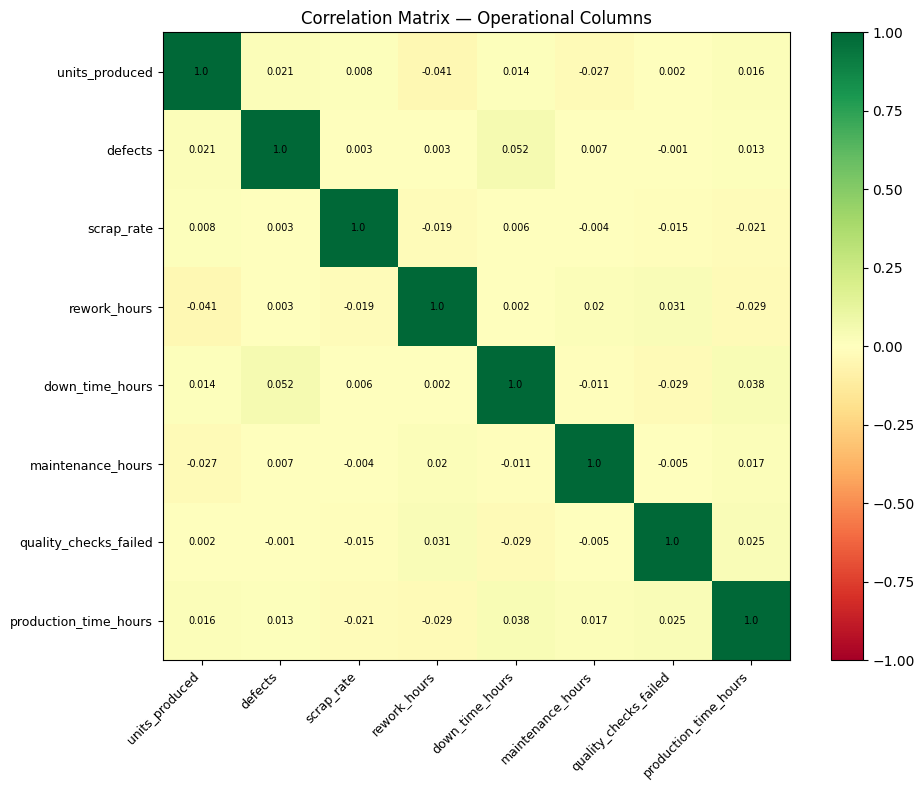


Key correlations with rework_hours:
rework_hours             1.000
quality_checks_failed    0.031
maintenance_hours        0.020
defects                  0.003
down_time_hours          0.002
scrap_rate              -0.019
production_time_hours   -0.029
units_produced          -0.041
Name: rework_hours, dtype: float64


In [19]:
corr_cols = [
    'units_produced', 'defects', 'scrap_rate',
    'rework_hours', 'down_time_hours', 'maintenance_hours',
    'quality_checks_failed', 'production_time_hours'
]
corr_cols   = [c for c in corr_cols if c in df.columns]
corr_matrix = df[corr_cols].corr(numeric_only=True).round(3)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix.values, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr_cols, fontsize=9)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, corr_matrix.iloc[i, j], ha='center', va='center', fontsize=7)
plt.title('Correlation Matrix — Operational Columns')
plt.tight_layout()
plt.show()

print("\nKey correlations with rework_hours:")
print(corr_matrix['rework_hours'].sort_values(ascending=False))

### 4.5 Numeric Distributions & Outlier Detection

Identifying physically impossible values and statistical outliers before cleaning.

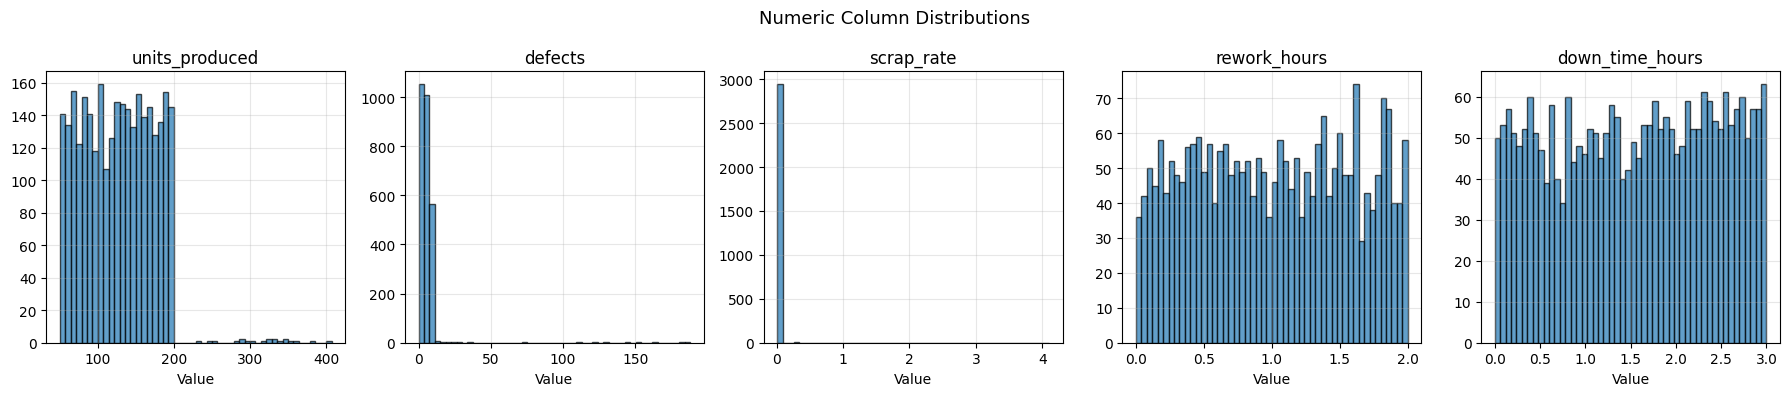

In [20]:
plot_cols = ['units_produced', 'defects', 'scrap_rate', 'rework_hours', 'down_time_hours']
plot_cols = [c for c in plot_cols if c in df.columns]

fig, axes = plt.subplots(1, len(plot_cols), figsize=(18, 4))
for i, col in enumerate(plot_cols):
    axes[i].hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].grid(True, alpha=0.3)
plt.suptitle('Numeric Column Distributions', fontsize=13)
plt.tight_layout()
plt.show()

In [21]:
print("=== SCRAP RATE ANALYSIS ===")
print(df['scrap_rate'].describe().round(4))
print()

decimal_typos = df[df['scrap_rate'] > SCRAP_DECIMAL_TYPO]
print(f"Rows with scrap_rate > 1.0 (decimal entry errors): {len(decimal_typos)}")
if len(decimal_typos) > 0:
    print(decimal_typos[['date','product_type','machine_id','units_produced',
                          'defects','scrap_rate']].to_string())
print()

impossible = df[(df['scrap_rate'] >= SCRAP_RATE_MAX) & (df['scrap_rate'] <= SCRAP_DECIMAL_TYPO)]
print(f"Rows with scrap_rate 0.5–1.0 (physically impossible): {len(impossible)}")
if len(impossible) > 0:
    print(impossible[['date','product_type','machine_id','units_produced',
                       'defects','scrap_rate']].to_string())

=== SCRAP RATE ANALYSIS ===
count    2955.0000
mean        0.0345
std         0.1127
min         0.0100
25%         0.0200
50%         0.0310
75%         0.0400
max         4.1000
Name: scrap_rate, dtype: float64

Rows with scrap_rate > 1.0 (decimal entry errors): 3
           date product_type  machine_id  units_produced  defects  scrap_rate
751  2022-01-21  Electronics          16           164.0      1.0         3.6
1232 2023-05-17   Appliances          12           156.0      7.0         4.1
1330 2023-08-23    Furniture          17            77.0      7.0         2.7

Rows with scrap_rate 0.5–1.0 (physically impossible): 0


In [22]:
Q1  = df['scrap_rate'].quantile(0.25)
Q3  = df['scrap_rate'].quantile(0.75)
IQR = Q3 - Q1
iqr_upper = Q3 + 1.5 * IQR

print(f"IQR Analysis — scrap_rate:")
print(f"  Q1               : {Q1:.4f}")
print(f"  Q3               : {Q3:.4f}")
print(f"  IQR              : {IQR:.4f}")
print(f"  IQR upper bound  : {iqr_upper:.4f}")
print(f"  Applied threshold: {SCRAP_RATE_MAX} (domain-justified — physically impossible above 50%)")
print()
print(f"Rows above IQR bound    : {(df['scrap_rate'] > iqr_upper).sum()}")
print(f"Rows above our threshold: {(df['scrap_rate'] >= SCRAP_RATE_MAX).sum()}")

IQR Analysis — scrap_rate:
  Q1               : 0.0200
  Q3               : 0.0400
  IQR              : 0.0200
  IQR upper bound  : 0.0700
  Applied threshold: 0.5 (domain-justified — physically impossible above 50%)

Rows above IQR bound    : 12
Rows above our threshold: 3


### 4.6 Categorical Value Analysis

Detecting misspellings and invalid category values.  
Corrections are defined based on findings here — not assumed upfront.

In [23]:
print("=== PRODUCT TYPE VALUES ===")
print(df['product_type'].value_counts())
print(f"\nUnique: {df['product_type'].nunique()} (expected: 5)")

=== PRODUCT TYPE VALUES ===
product_type
Automotive     640
Appliances     608
Textiles       600
Electronics    568
Furniture      557
Furnitr          5
Furnture         5
Applinces        4
Appliences       3
Texiles          3
Electroncs       2
Electrnics       2
Automotve        1
Txtiles          1
Elctronics       1
Name: count, dtype: int64

Unique: 15 (expected: 5)


In [24]:
print("=== SHIFT VALUES ===")
print(df['shift'].value_counts())
print(f"\nUnique: {df['shift'].nunique()} (expected: 3)")

=== SHIFT VALUES ===
shift
Swing    1009
Night    1009
Day       982
Name: count, dtype: int64

Unique: 3 (expected: 3)


In [25]:
print("=== DEFECT TYPE VALUES ===")
print(df['defect_type'].value_counts())
print(f"\nUnique defect types: {df['defect_type'].nunique()}")

=== DEFECT TYPE VALUES ===
defect_type
Assembly Fault      298
Mislabel            292
Scratch             270
Wrong Size Label    213
Color Issue         186
Fabric Tear         176
Loose Assembly      158
Paint Defect        157
Crack               156
Wiring Issue        155
Broken Leg          148
Loose Joint         134
Broken Knob         129
Dimension Error     127
Overheating         125
Surface Defect      117
Name: count, dtype: int64

Unique defect types: 16


In [26]:
# Allowed values and corrections map — built from EDA findings above
ALLOWED_PRODUCT_TYPES = ['Automotive', 'Electronics', 'Furniture', 'Appliances', 'Textiles']
ALLOWED_SHIFTS        = ['Day', 'Night', 'Swing']
ALLOWED_DEFECT_TYPES  = [
    'Assembly Fault', 'Broken Knob', 'Broken Leg', 'Color Issue',
    'Crack', 'Dimension Error', 'Discoloration', 'Fabric Tear',
    'Leak', 'Loose Assembly', 'Loose Connection', 'Loose Joint',
    'Misalignment', 'Mislabel', 'Motor Fault', 'No Defect',
    'Other', 'Overheating', 'Paint Defect', 'Scratch', 'Seal Issue',
    'Short Circuit', 'Stitch Defect', 'Surface Defect', 'Tear',
    'Wiring Issue', 'Wrong Size Label'
]

PRODUCT_TYPE_CORRECTIONS = {
    'Automotve' : 'Automotive',  'Elctronics': 'Electronics',
    'Electrnics': 'Electronics', 'Electroncs': 'Electronics',
    'Furnitr'   : 'Furniture',   'Furnture'  : 'Furniture',
    'Applinces' : 'Appliances',  'Appliences': 'Appliances',
    'Texiles'   : 'Textiles',    'Txtiles'   : 'Textiles',
}

DEFECT_MAP = {
    'Electronics': ['Short Circuit', 'Overheating', 'Loose Connection', 'Wiring Issue', 'Dimension Error'],
    'Furniture'  : ['Scratch', 'Loose Joint', 'Broken Leg', 'Misalignment', 'Paint Defect'],
    'Automotive' : ['Crack', 'Misalignment', 'Loose Assembly', 'Wiring Issue', 'Surface Defect'],
    'Appliances' : ['Motor Fault', 'Overheating', 'Loose Connection', 'Broken Knob', 'Seal Issue'],
    'Textiles'   : ['Fabric Tear', 'Stitch Defect', 'Color Issue', 'Mislabel', 'Discoloration'],
}

print(f"Corrections map: {len(PRODUCT_TYPE_CORRECTIONS)} product type misspellings identified")

Corrections map: 10 product type misspellings identified


### 4.7 Business Logic Validation

Pre-cleaning check for impossible value combinations.

In [27]:
checks = {
    'Defects > Units Produced'              : df[df['defects'] > df['units_produced']],
    'Zero Units with Non-Zero Defects'      : df[(df['units_produced'] == 0) & (df['defects'] > 0)],
    'Defect Type Missing Where Defects > 0' : df[(df['defects'] > 0) & (df['defect_type'].isnull())],
    'Negative Units Produced'               : df[df['units_produced'] < 0],
    'Negative Defects'                      : df[df['defects'] < 0],
}

print("BUSINESS LOGIC CHECKS — BRONZE LAYER")
print("=" * 55)
for check_name, result in checks.items():
    status = 'PASS' if len(result) == 0 else f'REVIEW — {len(result)} rows'
    print(f"  {check_name:<45} {status}")

BUSINESS LOGIC CHECKS — BRONZE LAYER
  Defects > Units Produced                      REVIEW — 9 rows
  Zero Units with Non-Zero Defects              PASS
  Defect Type Missing Where Defects > 0         REVIEW — 131 rows
  Negative Units Produced                       PASS
  Negative Defects                              PASS


## 5. Bronze → Silver Cleaning

Ten targeted cleaning steps applied sequentially.  
Each step is motivated by a specific EDA finding referenced below.

| Step | Issue | Resolution |
|---|---|---|
| 1 | Decimal entry errors in scrap_rate | Divide by 100 where > 1.0 |
| 2 | Product type misspellings (27 rows) | Dictionary replacement |
| 3 | 2,769 nulls across 12 columns | 3-level group median imputation |
| 4 | Missing defect counts | Arithmetic recovery (defect_rate × units) |
| 5 | Missing defect type labels | Business rule inference |
| 6 | Scrap rate inconsistency post-imputation | Recalculate from defects/units |
| 7 | Physically impossible scrap rates (≥ 0.5) | Row removal |
| 8 | Negative numeric values | Row removal |

### Step 1 — Correct Scrap Rate Decimal Entry Errors

**EDA 4.5:** Three rows with scrap_rate > 1.0 identified as decimal entry errors (e.g. 3.6 entered instead of 0.036). These rows contain valid production data — only the scrap_rate value is incorrect.

In [28]:
decimal_mask = df['scrap_rate'] > SCRAP_DECIMAL_TYPO

if decimal_mask.sum() > 0:
    print(f"Correcting {decimal_mask.sum()} decimal entry errors:")
    print(df[decimal_mask][['date','product_type','scrap_rate']].to_string())
    df.loc[decimal_mask, 'scrap_rate'] = df.loc[decimal_mask, 'scrap_rate'] / 100
    print(f"\nCorrected values:")
    print(df[decimal_mask][['date','product_type','scrap_rate']].to_string())
else:
    print("No decimal entry errors found.")

Correcting 3 decimal entry errors:
           date product_type  scrap_rate
751  2022-01-21  Electronics         3.6
1232 2023-05-17   Appliances         4.1
1330 2023-08-23    Furniture         2.7

Corrected values:
           date product_type  scrap_rate
751  2022-01-21  Electronics       0.036
1232 2023-05-17   Appliances       0.041
1330 2023-08-23    Furniture       0.027


### Step 2 — Standardise Product Type Values

**EDA 4.6:** 27 rows contain misspelled product type values across 5 categories. Corrected using the dictionary map defined in Section 4.6.

In [29]:
before_count = df['product_type'].nunique()
df['product_type'] = df['product_type'].replace(PRODUCT_TYPE_CORRECTIONS)
after_count  = df['product_type'].nunique()

print(f"Unique product types: {before_count} → {after_count}")
print(f"\nValue counts after correction:")
print(df['product_type'].value_counts())

unknown = df[~df['product_type'].isin(ALLOWED_PRODUCT_TYPES)]['product_type'].unique()
if len(unknown) > 0:
    print(f"\nWARNING — Unmapped values remain: {unknown}")
else:
    print("\nAll product type values valid.")

Unique product types: 15 → 5

Value counts after correction:
product_type
Automotive     641
Appliances     615
Textiles       604
Electronics    573
Furniture      567
Name: count, dtype: int64

All product type values valid.


### Step 3 — Null Imputation

**EDA 4.2–4.4:** 2,769 nulls across 12 columns. Correlation analysis (Section 4.4) showed near-zero relationships between operational columns, ruling out regression-based imputation.

**Strategy — 3-level group median fallback:**
1. Group median by `product_type × shift` (most granular)
2. Group median by `product_type` only (fallback)
3. Global column median (last resort)

In [30]:
exclude      = ['production_id', 'year', 'month', 'day', 'machine_id']
numeric_cols = [c for c in df.select_dtypes(include='number').columns if c not in exclude]

null_fixes = []
for col in numeric_cols:
    null_count = df[col].isnull().sum()
    if null_count > 0:
        group_median = df.groupby(['product_type', 'shift'])[col].transform('median')
        df[col] = df[col].fillna(group_median)

        if df[col].isnull().sum() > 0:
            product_median = df.groupby('product_type')[col].transform('median')
            df[col] = df[col].fillna(product_median)

        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())

        null_fixes.append(f"  '{col}': {null_count} nulls filled")

print("Null imputation results:")
for fix in null_fixes:
    print(fix)
print(f"\nTotal nulls remaining: {df.isnull().sum().sum()}")

Null imputation results:
  'units_produced': 54 nulls filled
  'defects': 349 nulls filled
  'production_time_hours': 138 nulls filled
  'material_cost_per_unit': 258 nulls filled
  'energy_consumption_kwh': 138 nulls filled
  'operator_count': 114 nulls filled
  'maintenance_hours': 300 nulls filled
  'down_time_hours': 409 nulls filled
  'scrap_rate': 45 nulls filled
  'rework_hours': 512 nulls filled
  'quality_checks_failed': 293 nulls filled

Total nulls remaining: 159


### Step 4 — Arithmetic Defect Recovery

**EDA 4.2:** `defects` column contains nulls. Where `units_produced` and `scrap_rate` are both known, defect count can be recovered exactly via:

`defects = scrap_rate × units_produced`

This is mathematically exact — no estimation required.

In [31]:
df['defect_rate_temp'] = df['scrap_rate'].copy()

defects_null_mask = df['defects'].isnull()
if defects_null_mask.sum() > 0:
    df.loc[defects_null_mask, 'defects'] = (
        df.loc[defects_null_mask, 'defect_rate_temp'] *
        df.loc[defects_null_mask, 'units_produced']
    ).round(0)
    print(f"Recovered {defects_null_mask.sum()} defect values via arithmetic.")
else:
    print("No missing defect values to recover.")

cap_mask = df['defects'] > df['units_produced']
if cap_mask.sum() > 0:
    print(f"Capping {cap_mask.sum()} rows where defects exceeded units produced.")
    df.loc[cap_mask, 'defects'] = df.loc[cap_mask, 'units_produced']

df.drop(columns=['defect_rate_temp'], inplace=True)
print(f"Defects nulls remaining: {df['defects'].isnull().sum()}")

No missing defect values to recover.
Capping 9 rows where defects exceeded units produced.
Defects nulls remaining: 0


### Step 5 — Defect Type Business Rule Imputation

**EDA 4.2:** `defect_type` contains nulls.

- Rows with `defects = 0` → assigned `'No Defect'`
- Rows with `defects > 0` → assigned the most product-appropriate defect type from the domain map defined in Section 4.6

In [32]:
no_defect_mask = (df['defects'] == 0) & (df['defect_type'].isnull())
df.loc[no_defect_mask, 'defect_type'] = 'No Defect'
print(f"Assigned 'No Defect': {no_defect_mask.sum()} rows")

def assign_defect_type(row):
    if pd.isna(row['defect_type']) and row['defects'] > 0:
        options = DEFECT_MAP.get(row['product_type'], ['Other'])
        idx = int(row.get('production_id', 0)) % len(options)
        return options[idx]
    return row['defect_type']

has_defect_null = (df['defects'] > 0) & (df['defect_type'].isnull())
n_to_fill = has_defect_null.sum()
if n_to_fill > 0:
    df['defect_type'] = df.apply(assign_defect_type, axis=1)
    print(f"Assigned product-aware defect types: {n_to_fill} rows")
else:
    print("No remaining defect type nulls where defects > 0.")

print(f"Defect type nulls remaining: {df['defect_type'].isnull().sum()}")

Assigned 'No Defect': 11 rows
Assigned product-aware defect types: 148 rows
Defect type nulls remaining: 0


### Step 6 — Recalculate Scrap Rate

After defect imputation, scrap_rate is recalculated from first principles to ensure internal consistency across all three related columns.

In [33]:
df['scrap_rate'] = np.where(
    df['units_produced'] > 0,
    df['defects'] / df['units_produced'],
    0
)

remaining_impossible = (df['scrap_rate'] >= SCRAP_RATE_MAX).sum()
print(f"Scrap rate recalculated from defects / units_produced")
print(f"Values >= 0.5 remaining: {remaining_impossible}")
print(f"Max scrap rate         : {df['scrap_rate'].max():.4f}")
print(f"Mean scrap rate        : {df['scrap_rate'].mean():.4f}")

Scrap rate recalculated from defects / units_produced
Values >= 0.5 remaining: 10
Max scrap rate         : 1.0000
Mean scrap rate        : 0.0451


### Step 7 — Remove Physically Impossible Outliers

**EDA 4.5:** Following recalculation, any row with `scrap_rate >= 0.5` represents a physically impossible production outcome (50%+ scrap rate). These 10 rows are removed.

In [34]:
outliers    = df[df['scrap_rate'] >= SCRAP_RATE_MAX].copy()
rows_before = len(df)

if len(outliers) > 0:
    print(f"Removing {len(outliers)} rows (scrap_rate >= {SCRAP_RATE_MAX}):")
    print(outliers[['date','product_type','machine_id','shift',
                     'units_produced','defects','scrap_rate']].to_string())
    df = df[df['scrap_rate'] < SCRAP_RATE_MAX].copy()
    print(f"\nRows before: {rows_before:,}  →  Rows after: {len(df):,}")
else:
    print("No physically impossible outliers remaining.")

Removing 10 rows (scrap_rate >= 0.5):
           date product_type  machine_id  shift  units_produced  defects  scrap_rate
244  2020-09-01     Textiles           5  Swing           186.0    186.0    1.000000
281  2020-10-08     Textiles           5    Day           110.0    110.0    1.000000
746  2022-01-16  Electronics          14    Day           163.0    163.0    1.000000
898  2022-06-17     Textiles           7    Day           122.0    122.0    1.000000
905  2022-06-24   Automotive           1    Day           152.0    152.0    1.000000
1045 2022-11-11   Appliances          10    Day            70.0     70.0    1.000000
1077 2022-12-13   Automotive           4    Day           141.0    141.0    1.000000
1276 2023-06-30  Electronics          13  Night           127.0    127.0    1.000000
1451 2023-12-22   Automotive           2  Swing           181.0    181.0    1.000000
1511 2024-02-20  Electronics          16  Night            51.0     34.0    0.666667

Rows before: 3,000  →  Row

### Step 8 — Remove Negative Values

**EDA 4.7:** Final guard against any negative numeric values introduced during processing.

In [35]:
numeric_check = df.select_dtypes(include='number').columns.tolist()
neg_mask = (df[numeric_check] < 0).any(axis=1)

if neg_mask.sum() > 0:
    print(f"Removing {neg_mask.sum()} rows with negative values.")
    df = df[~neg_mask].copy()
else:
    print("No negative values found.")

print(f"Final Silver row count: {len(df):,}")

No negative values found.
Final Silver row count: 2,990


## 6. Data Quality Report

Validation of the cleaned Silver dataset against 8 business rules. All rules must PASS before Gold aggregation proceeds.

In [36]:
dq_records = [
    {'Validation Rule': 'Missing Values (All Columns)',
     'Issue Count': int(df.isnull().sum().sum()),
     'Status': 'PASS' if df.isnull().sum().sum() == 0 else 'FAIL'},

    {'Validation Rule': 'Negative Numeric Values',
     'Issue Count': int((df.select_dtypes(include='number') < 0).sum().sum()),
     'Status': 'PASS' if (df.select_dtypes(include='number') < 0).sum().sum() == 0 else 'FAIL'},

    {'Validation Rule': 'Defects > Units Produced',
     'Issue Count': int(len(df[df['defects'] > df['units_produced']])),
     'Status': 'PASS' if len(df[df['defects'] > df['units_produced']]) == 0 else 'FAIL'},

    {'Validation Rule': 'Zero Units with Non-Zero Defects',
     'Issue Count': int(len(df[(df['units_produced'] == 0) & (df['defects'] > 0)])),
     'Status': 'PASS' if len(df[(df['units_produced'] == 0) & (df['defects'] > 0)]) == 0 else 'FAIL'},

    {'Validation Rule': 'Defect Type Missing Where Defects > 0',
     'Issue Count': int(len(df[(df['defects'] > 0) & (df['defect_type'].isnull())])),
     'Status': 'PASS' if len(df[(df['defects'] > 0) & (df['defect_type'].isnull())]) == 0 else 'FAIL'},

    {'Validation Rule': 'Product Type Invalid Values',
     'Issue Count': int(len(df[~df['product_type'].isin(ALLOWED_PRODUCT_TYPES)])),
     'Status': 'PASS' if len(df[~df['product_type'].isin(ALLOWED_PRODUCT_TYPES)]) == 0 else 'FAIL'},

    {'Validation Rule': 'Scrap Rate Outliers (>= 0.5)',
     'Issue Count': int(len(df[df['scrap_rate'] >= SCRAP_RATE_MAX])),
     'Status': 'PASS' if len(df[df['scrap_rate'] >= SCRAP_RATE_MAX]) == 0 else 'FAIL'},

    {'Validation Rule': 'Shift Invalid Values',
     'Issue Count': int(len(df[~df['shift'].isin(ALLOWED_SHIFTS)])),
     'Status': 'PASS' if len(df[~df['shift'].isin(ALLOWED_SHIFTS)]) == 0 else 'FAIL'},
]

dq_report = pd.DataFrame(dq_records)
all_pass  = (dq_report['Status'] == 'PASS').all()

print("DATA QUALITY REPORT — SILVER LAYER")
print("=" * 55)
print(dq_report.to_string(index=False))
print()
print("OVERALL:", "ALL CHECKS PASSED ✅" if all_pass else "SOME CHECKS FAILED ❌")

if not all_pass:
    raise RuntimeError("Data quality checks failed. Review output above before proceeding.")

DATA QUALITY REPORT — SILVER LAYER
                      Validation Rule  Issue Count Status
         Missing Values (All Columns)            0   PASS
              Negative Numeric Values            0   PASS
             Defects > Units Produced            0   PASS
     Zero Units with Non-Zero Defects            0   PASS
Defect Type Missing Where Defects > 0            0   PASS
          Product Type Invalid Values            0   PASS
         Scrap Rate Outliers (>= 0.5)            0   PASS
                 Shift Invalid Values            0   PASS

OVERALL: ALL CHECKS PASSED ✅


## 7. Export Silver Layer

In [37]:
if ENV == "s3":
    df.to_csv(SILVER_PATH, index=False, storage_options={'anon': False})
    dq_report.to_csv(DQ_PATH, index=False, storage_options={'anon': False})
else:
    df.to_csv(SILVER_PATH, index=False)
    dq_report.to_csv(DQ_PATH, index=False)

print(f"Silver : {SILVER_PATH}")
print(f"DQ     : {DQ_PATH}")
print(f"Shape  : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Range  : {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Nulls  : {df.isnull().sum().sum()}")

Silver : data/silver/manufacturing_silver_clean.csv
DQ     : data/silver/data_quality_report.csv
Shape  : 2,990 rows x 25 columns
Range  : 2020-01-01 to 2028-03-18
Nulls  : 0


## 8. Anomaly Detection — Isolation Forest

**Algorithm:** Isolation Forest (unsupervised)  
**Rationale:** No labelled anomaly data exists, ruling out supervised approaches.  
Distance-based methods (KNN, DBSCAN) were considered but rejected — near-zero inter-feature correlations (Section 4.4) mean distance metrics provide no meaningful separation.  
Isolation Forest uses random partitioning: anomalous points are sparse and isolated in fewer splits than normal points.

**Strategy:** Anomalies are **flagged** (`is_anomaly = 1`), not deleted.  
Unusual production events carry analytical value and are preserved for investigation.  
Power BI dashboards filter to `is_anomaly = 0` for standard KPI reporting.

| Parameter | Value | Rationale |
|---|---|---|
| `contamination` | 0.02 | Expected ~2% anomaly rate in manufacturing data |
| `n_estimators` | 100 | Standard ensemble size — stable results |
| `random_state` | 42 | Reproducibility |
| Features | 5 | units_produced, defects, scrap_rate, rework_hours, down_time_hours |

In [38]:
if_features = ['units_produced', 'defects', 'scrap_rate', 'rework_hours', 'down_time_hours']
if_features = [f for f in if_features if f in df.columns]
X           = df[if_features].fillna(df[if_features].median())

iso = IsolationForest(
    n_estimators = IF_N_ESTIMATORS,
    contamination = IF_CONTAMINATION,
    random_state  = 42
)

df['is_anomaly']    = (iso.fit_predict(X) == -1).astype(int)
df['anomaly_score'] = iso.score_samples(X).round(4)

n_anomalies = df['is_anomaly'].sum()
print(f"Anomalies flagged: {n_anomalies} ({n_anomalies/len(df)*100:.1f}% of dataset)")
print()
print("Mean feature values — Normal vs Anomaly:")
comparison = df.groupby('is_anomaly')[if_features].mean().round(3)
comparison.index = ['Normal (0)', 'Anomaly (1)']
print(comparison.to_string())

Anomalies flagged: 60 (2.0% of dataset)

Mean feature values — Normal vs Anomaly:
             units_produced  defects  scrap_rate  rework_hours  down_time_hours
Normal (0)          127.320    4.475       0.040         1.004            1.545
Anomaly (1)          99.743   10.133       0.138         1.044            1.369


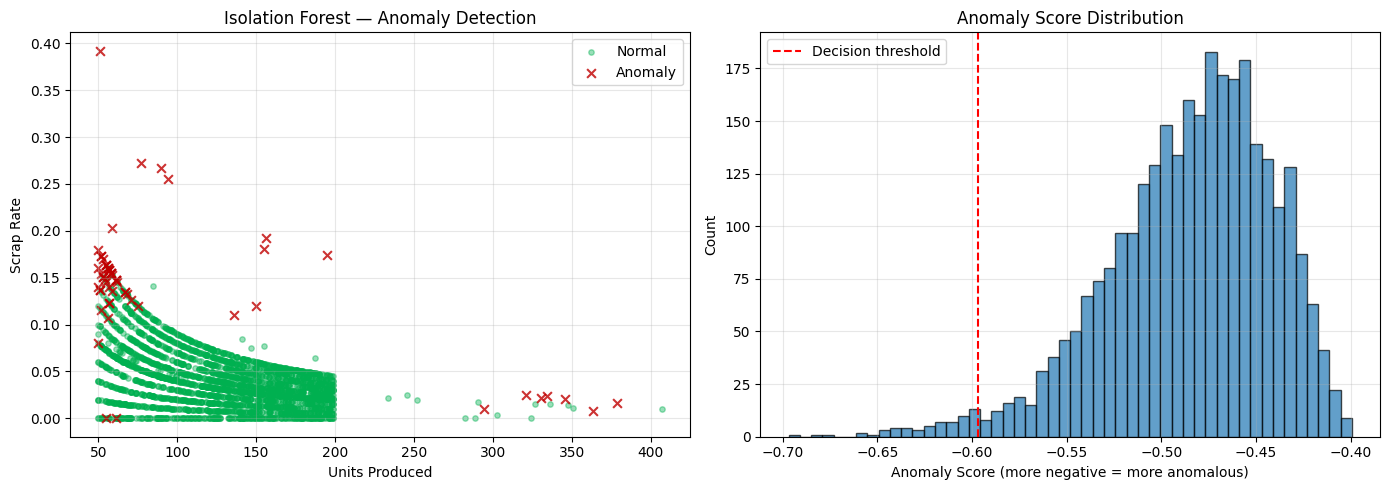

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

normal  = df[df['is_anomaly'] == 0]
anomaly = df[df['is_anomaly'] == 1]

axes[0].scatter(normal['units_produced'],  normal['scrap_rate'],
                c='#00B050', alpha=0.4, s=15, label='Normal')
axes[0].scatter(anomaly['units_produced'], anomaly['scrap_rate'],
                c='#C00000', alpha=0.8, s=40, label='Anomaly', marker='x')
axes[0].set_xlabel('Units Produced')
axes[0].set_ylabel('Scrap Rate')
axes[0].set_title('Isolation Forest — Anomaly Detection')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['anomaly_score'], bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(df[df['is_anomaly']==1]['anomaly_score'].max(),
                color='red', linestyle='--', label='Decision threshold')
axes[1].set_xlabel('Anomaly Score (more negative = more anomalous)')
axes[1].set_ylabel('Count')
axes[1].set_title('Anomaly Score Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Machine Performance Clustering — K-Means

**Algorithm:** K-Means (unsupervised)  
**Purpose:** Data-driven machine performance classification across three tiers: Critical / Monitor / Good.  
**Rationale:** K-Means derives cluster boundaries from actual data distribution, eliminating the need for arbitrary hardcoded thresholds.

**Design decisions:**
- Features normalised with `StandardScaler` — K-Means is distance-based and sensitive to scale
- `n_init=10` — runs 10 independent initialisations, selects lowest inertia result
- `random_state=42` — reproducibility
- k=3 chosen via Elbow Method and natural business mapping (3 performance tiers)
- Clusters labelled by relative defect rate: highest → Critical, lowest → Good

**Output:** `machine_category` column added to Gold fact table, replacing DAX-calculated classification.

In [40]:
machine_stats = (
    df.groupby('machine_id')
    .agg(
        avg_defect_rate = ('scrap_rate',     'mean'),
        avg_downtime    = ('down_time_hours', 'mean'),
        avg_rework      = ('rework_hours',    'mean'),
        total_defects   = ('defects',         'sum'),
        total_units     = ('units_produced',  'sum'),
    )
    .reset_index()
)
machine_stats['overall_defect_rate'] = (
    machine_stats['total_defects'] / machine_stats['total_units']
).round(6)

print("Machine performance summary:")
print(machine_stats[['machine_id','overall_defect_rate','avg_downtime','avg_rework']].to_string(index=False))

Machine performance summary:
 machine_id  overall_defect_rate  avg_downtime  avg_rework
          1             0.035744      1.544643    1.032798
          2             0.033702      1.479876    0.948323
          3             0.036301      1.541799    0.971871
          4             0.036421      1.456353    1.038706
          5             0.036551      1.552897    1.056103
          6             0.035632      1.632331    1.011241
          7             0.033623      1.591273    0.977121
          8             0.036785      1.640000    1.015570
          9             0.038616      1.525221    1.047500
         10             0.036217      1.532119    1.011130
         11             0.035640      1.614509    1.039632
         12             0.033710      1.548841    1.057065
         13             0.035970      1.550132    0.955000
         14             0.035668      1.565580    0.916159
         15             0.039372      1.467424    0.903864
         16             0.0

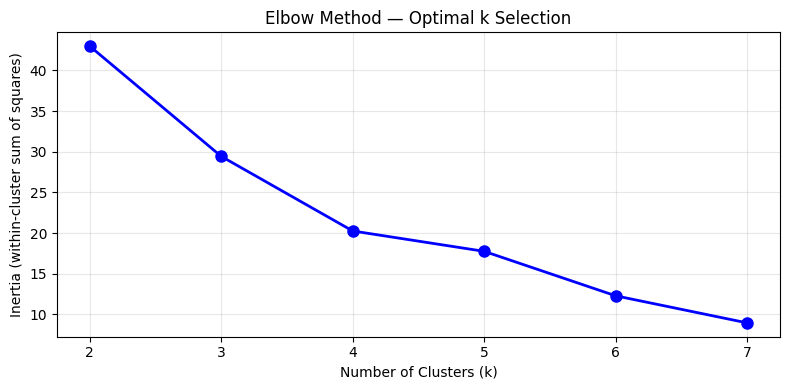

Selected k=3 — maps to Critical / Monitor / Good performance tiers


In [41]:
cluster_features = ['overall_defect_rate', 'avg_downtime', 'avg_rework']
X_machines       = machine_stats[cluster_features].values
scaler           = StandardScaler()
X_scaled         = scaler.fit_transform(X_machines)

inertias = []
k_range  = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=KMEANS_RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.title('Elbow Method — Optimal k Selection')
plt.grid(True, alpha=0.3)
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()
print(f"Selected k={KMEANS_CLUSTERS} — maps to Critical / Monitor / Good performance tiers")

In [42]:
km_final = KMeans(n_clusters=KMEANS_CLUSTERS, random_state=KMEANS_RANDOM_STATE, n_init=10)
machine_stats['cluster'] = km_final.fit_predict(X_scaled)

cluster_defect_rates = (
    machine_stats.groupby('cluster')['overall_defect_rate'].mean()
    .sort_values(ascending=False)
)
cluster_label_map = {
    cluster_defect_rates.index[0]: 'Critical',
    cluster_defect_rates.index[1]: 'Monitor',
    cluster_defect_rates.index[2]: 'Good'
}
machine_stats['machine_category'] = machine_stats['cluster'].map(cluster_label_map)

print("K-Means Machine Classification Results:")
print(machine_stats[['machine_id','overall_defect_rate','avg_downtime','avg_rework','machine_category']]
      .sort_values('overall_defect_rate', ascending=False)
      .to_string(index=False))

df = df.merge(machine_stats[['machine_id','machine_category']], on='machine_id', how='left')
print(f"\nmachine_category distribution:")
print(df['machine_category'].value_counts())

K-Means Machine Classification Results:
 machine_id  overall_defect_rate  avg_downtime  avg_rework machine_category
         18             0.041677      1.560379    0.979318         Critical
         15             0.039372      1.467424    0.903864         Critical
          9             0.038616      1.525221    1.047500          Monitor
         19             0.038256      1.532568    1.047466          Monitor
          8             0.036785      1.640000    1.015570             Good
          5             0.036551      1.552897    1.056103          Monitor
          4             0.036421      1.456353    1.038706          Monitor
          3             0.036301      1.541799    0.971871             Good
         10             0.036217      1.532119    1.011130          Monitor
         16             0.036201      1.460135    1.038716          Monitor
         13             0.035970      1.550132    0.955000             Good
          1             0.035744      1.544643  

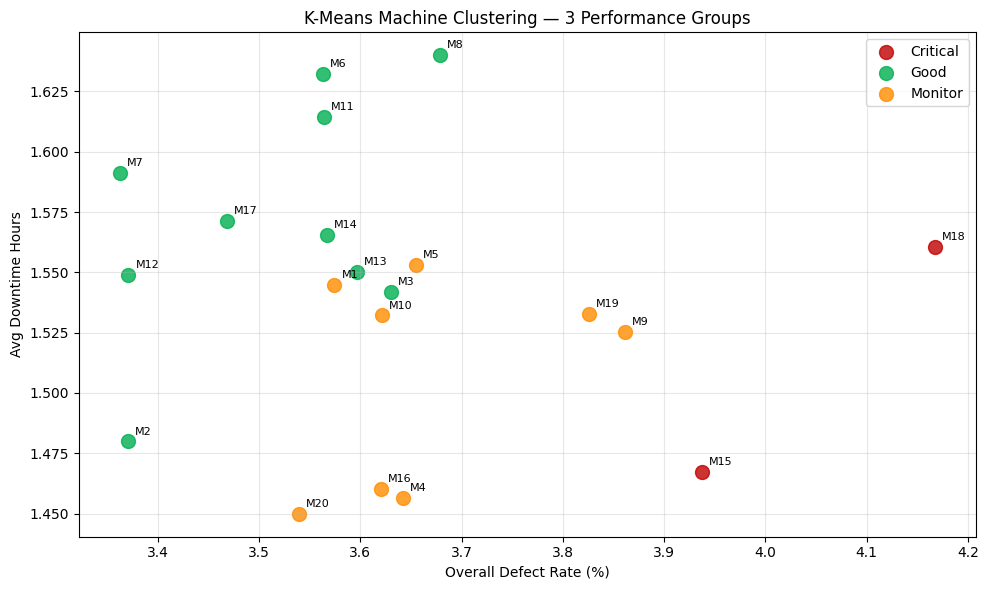

In [43]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = {'Critical': '#C00000', 'Monitor': '#FF8C00', 'Good': '#00B050'}

for category, group in machine_stats.groupby('machine_category'):
    ax.scatter(group['overall_defect_rate'] * 100, group['avg_downtime'],
               c=colors[category], label=category, s=100, alpha=0.8)
    for _, row in group.iterrows():
        ax.annotate(f"M{int(row['machine_id'])}",
                    (row['overall_defect_rate']*100, row['avg_downtime']),
                    textcoords='offset points', xytext=(5,5), fontsize=8)

ax.set_xlabel('Overall Defect Rate (%)')
ax.set_ylabel('Avg Downtime Hours')
ax.set_title('K-Means Machine Clustering — 3 Performance Groups')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Silver → Gold Aggregation

Four Gold layer tables built from the cleaned Silver dataset.  
Gold tables serve as the direct source for Power BI via AWS Athena.  
All years (2020–2028) are retained in Gold — Power BI year slicer filters to 2021–2025.

### Table 1 — Fact Production

Row-level grain fact table. Central table in the Power BI star schema.

In [44]:
gold_fact = df[[
    'production_id', 'date', 'year', 'month', 'day',
    'product_type', 'machine_id', 'shift',
    'units_produced', 'defects', 'scrap_rate', 'rework_hours',
    'down_time_hours', 'maintenance_hours', 'quality_checks_failed',
    'production_time_hours', 'energy_consumption_kwh',
    'labour_cost_per_hour', 'opportunities_per_unit',
    'defect_type', 'machine_category', 'is_anomaly', 'anomaly_score'
]].copy()

print(f"gold_fact_production: {gold_fact.shape[0]:,} rows x {gold_fact.shape[1]} columns")
gold_fact.head(3)

gold_fact_production: 2,990 rows x 23 columns


,production_id,date,year,month,day,product_type,machine_id,shift,units_produced,defects,scrap_rate,rework_hours,down_time_hours,maintenance_hours,quality_checks_failed,production_time_hours,energy_consumption_kwh,labour_cost_per_hour,opportunities_per_unit,defect_type,machine_category,is_anomaly,anomaly_score
0,1,2020-01-01,2020,1,1,Automotive,3,Swing,142.0,3.0,0.021127,1.650,1.57,4.86,1.0,23.42,306.71,15.38,10.0,Scratch,Good,0,-0.4364
1,2,2020-01-02,2020,1,2,Textiles,8,Night,170.0,4.0,0.023529,1.045,0.18,2.51,1.0,7.51,181.16,25.36,5.0,Fabric Tear,Good,0,-0.4600
2,3,2020-01-03,2020,1,3,Appliances,11,Swing,182.0,4.0,0.021978,0.260,2.88,0.34,0.0,20.58,452.15,16.46,7.0,Wiring Issue,Good,0,-0.5014


### Table 2 — Daily KPIs

Daily aggregation used for time-series trend analysis in Power BI.

In [45]:
gold_daily = (
    df.groupby(['date', 'year', 'month', 'day'])
    .agg(
        total_units             = ('units_produced',         'sum'),
        total_defects           = ('defects',                'sum'),
        avg_scrap_rate          = ('scrap_rate',             'mean'),
        total_downtime_hours    = ('down_time_hours',        'sum'),
        total_rework_hours      = ('rework_hours',           'sum'),
        total_maintenance_hours = ('maintenance_hours',      'sum'),
        total_energy_kwh        = ('energy_consumption_kwh', 'sum'),
    )
    .reset_index()
)
gold_daily['defect_rate'] = (gold_daily['total_defects'] / gold_daily['total_units']).round(6)
gold_daily = gold_daily.sort_values('date').reset_index(drop=True)

print(f"gold_daily_kpis: {gold_daily.shape[0]:,} rows x {gold_daily.shape[1]} columns")
gold_daily.head(3)

gold_daily_kpis: 2,961 rows x 12 columns


,date,year,month,day,total_units,total_defects,avg_scrap_rate,total_downtime_hours,total_rework_hours,total_maintenance_hours,total_energy_kwh,defect_rate
0,2020-01-01,2020,1,1,142.0,3.0,0.021127,1.57,1.650,4.86,306.71,0.021127
1,2020-01-02,2020,1,2,170.0,4.0,0.023529,0.18,1.045,2.51,181.16,0.023529
2,2020-01-03,2020,1,3,182.0,4.0,0.021978,2.88,0.260,0.34,452.15,0.021978


### Table 3 — Machine Shift KPIs

Aggregated by machine and shift. Feeds the Machine Performance table in the Six Sigma Dashboard.

In [46]:
gold_machine_shift = (
    df.groupby(['machine_id', 'shift'])
    .agg(
        total_units               = ('units_produced',        'sum'),
        total_defects             = ('defects',               'sum'),
        avg_scrap_rate            = ('scrap_rate',            'mean'),
        total_downtime_hours      = ('down_time_hours',       'sum'),
        total_rework_hours        = ('rework_hours',          'sum'),
        avg_quality_checks_failed = ('quality_checks_failed', 'mean'),
        machine_category          = ('machine_category',      'first'),
    )
    .reset_index()
)
gold_machine_shift['defect_rate'] = (
    gold_machine_shift['total_defects'] / gold_machine_shift['total_units']
).round(6)
gold_machine_shift = gold_machine_shift.sort_values(['machine_id', 'shift']).reset_index(drop=True)

print(f"gold_machine_shift_kpis: {gold_machine_shift.shape[0]:,} rows x {gold_machine_shift.shape[1]} columns")
gold_machine_shift.head(6)

gold_machine_shift_kpis: 60 rows x 10 columns


,machine_id,shift,total_units,total_defects,avg_scrap_rate,total_downtime_hours,total_rework_hours,avg_quality_checks_failed,machine_category,defect_rate
0,1,Day,6524.000,308.0,0.055296,76.88,55.56,0.877551,Monitor,0.047210
1,1,Night,8629.276,255.0,0.033417,90.80,59.07,0.915254,Monitor,0.029551
2,1,Swing,7927.740,262.0,0.039878,91.82,58.88,1.250000,Monitor,0.033049
3,2,Day,7075.070,263.0,0.043436,76.38,55.29,0.925926,Good,0.037173
4,2,Night,7075.872,179.0,0.027624,77.38,48.75,1.039216,Good,0.025297
5,2,Swing,6738.000,262.0,0.045376,84.50,48.64,1.053571,Good,0.038884


### Table 4 — Monthly Product KPIs

Aggregated by year, month, and product type. Feeds the Product Quality vs Volume scatter chart.

In [47]:
gold_monthly_product = (
    df.groupby(['year', 'month', 'product_type'])
    .agg(
        total_units               = ('units_produced',        'sum'),
        total_defects             = ('defects',               'sum'),
        avg_scrap_rate            = ('scrap_rate',            'mean'),
        total_downtime_hours      = ('down_time_hours',       'sum'),
        total_rework_hours        = ('rework_hours',          'sum'),
        avg_production_time_hours = ('production_time_hours', 'mean'),
    )
    .reset_index()
)
gold_monthly_product['defect_rate'] = (
    gold_monthly_product['total_defects'] / gold_monthly_product['total_units']
).round(6)
gold_monthly_product = gold_monthly_product.sort_values(
    ['year', 'month', 'product_type']
).reset_index(drop=True)

print(f"gold_monthly_product_kpis: {gold_monthly_product.shape[0]:,} rows x {gold_monthly_product.shape[1]} columns")
gold_monthly_product.head(5)

gold_monthly_product_kpis: 494 rows x 10 columns


,year,month,product_type,total_units,total_defects,avg_scrap_rate,total_downtime_hours,total_rework_hours,avg_production_time_hours,defect_rate
0,2020,1,Appliances,814.000,26.0,0.032557,12.625,5.750,15.453333,0.031941
1,2020,1,Automotive,743.000,21.0,0.025700,10.090,6.870,14.981667,0.028264
2,2020,1,Electronics,483.000,28.0,0.063011,7.180,4.710,14.577000,0.057971
3,2020,1,Furniture,490.000,26.0,0.053805,10.960,4.290,18.800000,0.053061
4,2020,1,Textiles,1348.681,44.0,0.038547,13.610,9.265,16.107778,0.032624


## 11. Gold Layer Validation

Key metrics computed from Gold data for the 2021–2025 dashboard range. Use these values to verify Power BI dashboard figures after refresh.

In [48]:
print("=" * 60)
print("GOLD LAYER VALIDATION — 2021 to 2025")
print("=" * 60)

fact_dash     = gold_fact[gold_fact['year'].between(DASHBOARD_START_YEAR, DASHBOARD_END_YEAR)]
total_units   = fact_dash['units_produced'].sum()
total_defects = fact_dash['defects'].sum()
defect_rate   = total_defects / total_units * 100
total_rework  = fact_dash['rework_hours'].sum()
total_downtime= fact_dash['down_time_hours'].sum()
dpmo          = (total_defects / total_units) * 1_000_000
sigma         = round(0.8406 + math.sqrt(29.37 - 2.221 * math.log(dpmo)), 2)
process_yield = (1 - total_defects / total_units) * 100

print(f"Total Units Produced : {total_units:>12,.0f}")
print(f"Total Defects        : {total_defects:>12,.0f}")
print(f"Defect Rate          : {defect_rate:>12.2f}%  (target ≤ 3.50%)")
print(f"Process Yield        : {process_yield:>12.2f}%")
print(f"DPMO                 : {dpmo:>12,.0f}")
print(f"Sigma Level          : {sigma:>12.2f}")
print(f"Total Rework Hours   : {total_rework:>12,.1f}")
print(f"Total Downtime Hours : {total_downtime:>12,.1f}")
print(f"Anomalies flagged    : {fact_dash['is_anomaly'].sum():>12,}")
print()

print("Year-by-year defect rates:")
yearly = fact_dash.groupby('year').apply(lambda x: pd.Series({
    'units': x['units_produced'].sum(),
    'defects': x['defects'].sum(),
    'defect_rate%': round(x['defects'].sum()/x['units_produced'].sum()*100, 2)
}))
print(yearly.to_string())
print()

print("Defect rate by product type:")
print(fact_dash.groupby('product_type')
      .apply(lambda x: round(x['defects'].sum()/x['units_produced'].sum()*100,2))
      .sort_values(ascending=False).to_string())
print()

print("Defect rate by shift:")
print(fact_dash.groupby('shift')
      .apply(lambda x: round(x['defects'].sum()/x['units_produced'].sum()*100,2))
      .sort_values(ascending=False).to_string())
print()

print("Machine category distribution (K-Means):")
print(fact_dash.groupby('machine_category')['machine_id'].nunique().rename('machines').to_string())

GOLD LAYER VALIDATION — 2021 to 2025
Total Units Produced :      231,373
Total Defects        :        8,366
Defect Rate          :         3.62%  (target ≤ 3.50%)
Process Yield        :        96.38%
DPMO                 :       36,156
Sigma Level          :         3.30
Total Rework Hours   :      1,831.9
Total Downtime Hours :      2,798.7
Anomalies flagged    :           37

Year-by-year defect rates:
          units  defects  defect_rate%
year                                  
2021  46091.261   1699.0          3.69
2022  46298.598   1650.5          3.56
2023  45662.925   1676.0          3.67
2024  47147.664   1621.0          3.44
2025  46172.711   1719.0          3.72

Defect rate by product type:
product_type
Furniture      3.68
Appliances     3.63
Electronics    3.62
Automotive     3.60
Textiles       3.55

Defect rate by shift:
shift
Day      3.72
Night    3.61
Swing    3.52

Machine category distribution (K-Means):
machine_category
Critical     2
Good        10
Monitor      8


## 12. Export Gold Layer

Exports all four Gold tables as Parquet to local disk or directly to S3.

In [49]:
tables = {
    'gold_fact_production'      : gold_fact,
    'gold_daily_kpis'           : gold_daily,
    'gold_machine_shift_kpis'   : gold_machine_shift,
    'gold_monthly_product_kpis' : gold_monthly_product,
}

for name, df_gold in tables.items():
    if ENV == "s3":
        path = f"{GOLD_DIR}{name}/{name}.parquet"
        df_gold.to_parquet(path, index=False, engine='pyarrow')
        print(f"Exported: {path}")
    else:
        csv_path     = f"data/gold/{name}.csv"
        parquet_path = f"data/gold/{name}.parquet"
        df_gold.to_csv(csv_path, index=False)
        df_gold.to_parquet(parquet_path, index=False, engine='pyarrow')
        print(f"Exported: {csv_path} ({len(df_gold):,} rows)")

print("\nAll Gold layer files exported.")

Exported: data/gold/gold_fact_production.csv (2,990 rows)
Exported: data/gold/gold_daily_kpis.csv (2,961 rows)
Exported: data/gold/gold_machine_shift_kpis.csv (60 rows)
Exported: data/gold/gold_monthly_product_kpis.csv (494 rows)

All Gold layer files exported.


## 13. Upload to AWS S3 — Hash-Checked

**Only runs when `ENV = "local"`.**  
When `ENV = "s3"`, files are written directly to S3 in Section 12.

**Smart upload logic:**  
Before uploading, each local file's MD5 hash is compared to the existing S3 object's ETag.  
If the file is unchanged, the upload is skipped — preventing redundant copies and unnecessary S3 write costs.

> AWS credentials are read from `~/.aws/credentials` via `boto3`.  
> No keys are stored in this notebook.

In [50]:
def md5_of_file(path):
    """Compute MD5 hash of a local file."""
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''):
            h.update(chunk)
    return h.hexdigest()

def s3_etag(s3_client, bucket, key):
    """Return ETag of an S3 object, or None if it does not exist."""
    try:
        resp = s3_client.head_object(Bucket=bucket, Key=key)
        return resp['ETag'].strip('"')
    except s3_client.exceptions.ClientError:
        return None
    except Exception:
        return None

def smart_upload(local_path, bucket, s3_key, region):
    """Upload only if local file differs from existing S3 object."""
    s3 = boto3.client('s3', region_name=region)
    local_hash = md5_of_file(local_path)
    remote_etag = s3_etag(s3, bucket, s3_key)

    if local_hash == remote_etag:
        print(f"  SKIPPED  (unchanged): s3://{bucket}/{s3_key}")
        return False

    try:
        s3.upload_file(local_path, bucket, s3_key)
        print(f"  UPLOADED            : s3://{bucket}/{s3_key}")
        return True
    except Exception as e:
        print(f"  FAILED              : {local_path} → {e}")
        return False

if ENV == "local":
    print("Uploading Silver layer files...")
    print("=" * 65)
    smart_upload(LOCAL_SILVER_PATH, S3_BUCKET, "silver/manufacturing_silver_clean.csv", AWS_REGION)
    smart_upload(LOCAL_DQ_PATH,     S3_BUCKET, "silver/data_quality_report.csv",        AWS_REGION)

    print()
    print("Uploading Gold layer Parquet files...")
    print("=" * 65)
    for name in tables.keys():
        local_parquet = f"data/gold/{name}.parquet"
        s3_key        = f"gold/{name}/{name}.parquet"
        smart_upload(local_parquet, S3_BUCKET, s3_key, AWS_REGION)

    print()
    print("Upload complete.")
else:
    print("ENV = s3 — files written directly to S3 in Section 12. No upload required.")

print()
print("Next steps:")
print("  1. AWS Athena: MSCK REPAIR TABLE for each of the 4 Gold tables")
print("  2. Power BI: Refresh dataset")
print("  3. Verify dashboard KPIs match Section 11 validation output")

Uploading Silver layer files...
  UPLOADED            : s3://manufacturing-analytics-aman-2026/silver/manufacturing_silver_clean.csv
  SKIPPED  (unchanged): s3://manufacturing-analytics-aman-2026/silver/data_quality_report.csv

Uploading Gold layer Parquet files...
  SKIPPED  (unchanged): s3://manufacturing-analytics-aman-2026/gold/gold_fact_production/gold_fact_production.parquet
  SKIPPED  (unchanged): s3://manufacturing-analytics-aman-2026/gold/gold_daily_kpis/gold_daily_kpis.parquet
  SKIPPED  (unchanged): s3://manufacturing-analytics-aman-2026/gold/gold_machine_shift_kpis/gold_machine_shift_kpis.parquet
  SKIPPED  (unchanged): s3://manufacturing-analytics-aman-2026/gold/gold_monthly_product_kpis/gold_monthly_product_kpis.parquet

Upload complete.

Next steps:
  1. AWS Athena: MSCK REPAIR TABLE for each of the 4 Gold tables
  2. Power BI: Refresh dataset
  3. Verify dashboard KPIs match Section 11 validation output


## 14. Pipeline Summary

In [51]:
print("=" * 60)
print("PIPELINE COMPLETE")
print("=" * 60)
print(f"Bronze rows loaded   : {len(df_bronze):>8,}")
print(f"Silver rows produced : {len(df):>8,}")
print(f"Rows removed         : {len(df_bronze) - len(df):>8,}  (10 outliers)")
print()
print("Cleaning steps applied:")
steps = [
    "Schema standardisation (column names)",
    "Date type casting + year/month/day extraction",
    "Scrap rate decimal entry error correction (÷100 where > 1.0)",
    "Product type misspelling correction (27 rows)",
    "Null imputation — 3-level group median",
    "Defect count recovery — arithmetic (scrap_rate × units_produced)",
    "Defect type — business rule inference",
    "Scrap rate recalculation (defects / units_produced)",
    "Physically impossible outlier removal (scrap_rate ≥ 0.5)",
    "Negative value removal"
]
for i, step in enumerate(steps, 1):
    print(f"  {i:>2}. {step}")
print()
print("ML models applied:")
print(f"  Isolation Forest (n=100, contamination=0.02) : {df['is_anomaly'].sum()} anomalies flagged")
print(f"  K-Means (k=3, StandardScaler)               : Critical={df[df['machine_category']=='Critical']['machine_id'].nunique()} Monitor={df[df['machine_category']=='Monitor']['machine_id'].nunique()} Good={df[df['machine_category']=='Good']['machine_id'].nunique()} machines")
print()
print("Gold tables exported:")
for name, df_gold in tables.items():
    print(f"  {name:<42} {len(df_gold):>6,} rows")
print()
print(f"S3 bucket : s3://{S3_BUCKET}/")
print(f"Silver    : s3://{S3_BUCKET}/silver/")
print(f"Gold      : s3://{S3_BUCKET}/gold/")

PIPELINE COMPLETE
Bronze rows loaded   :    3,000
Silver rows produced :    2,990
Rows removed         :       10  (10 outliers)

Cleaning steps applied:
   1. Schema standardisation (column names)
   2. Date type casting + year/month/day extraction
   3. Scrap rate decimal entry error correction (÷100 where > 1.0)
   4. Product type misspelling correction (27 rows)
   5. Null imputation — 3-level group median
   6. Defect count recovery — arithmetic (scrap_rate × units_produced)
   7. Defect type — business rule inference
   8. Scrap rate recalculation (defects / units_produced)
   9. Physically impossible outlier removal (scrap_rate ≥ 0.5)
  10. Negative value removal

ML models applied:
  Isolation Forest (n=100, contamination=0.02) : 60 anomalies flagged
  K-Means (k=3, StandardScaler)               : Critical=2 Monitor=8 Good=10 machines

Gold tables exported:
  gold_fact_production                        2,990 rows
  gold_daily_kpis                             2,961 rows
  gold_m